4 cechy o najwyższej wariancji to: ['total sulfur dioxide', 'free sulfur dioxide', 'residual sugar', 'alcohol']



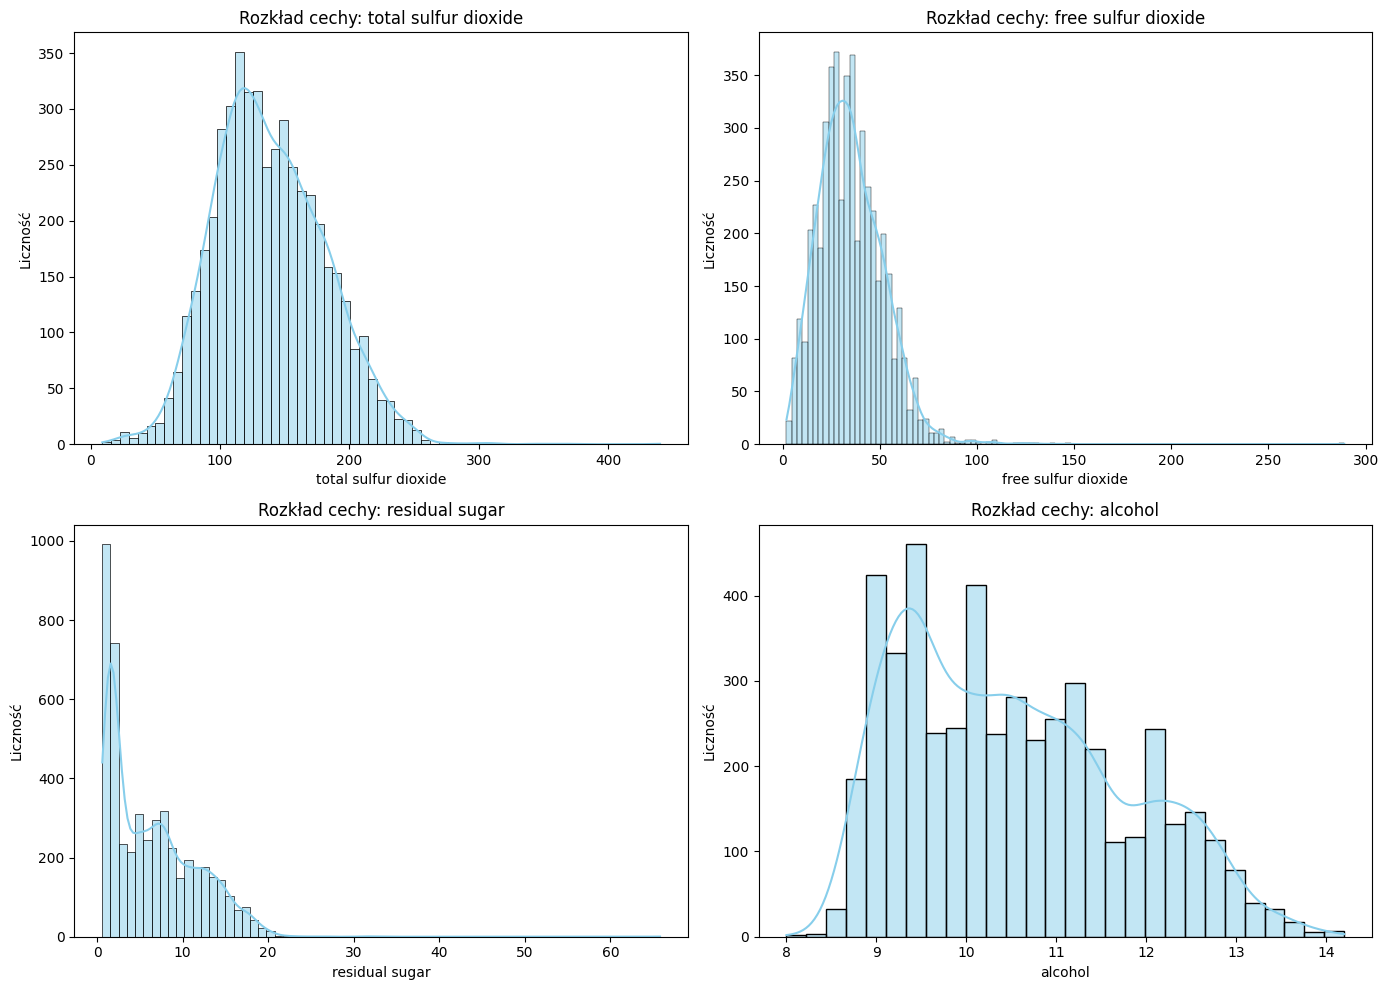

In [3]:
##zadanie 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('winequality-white.csv', sep=';')

wariancje = df.var()

top_4_cechy = wariancje.nlargest(4).index.tolist()
print(f"4 cechy o najwyższej wariancji to: {top_4_cechy}\n")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cecha in enumerate(top_4_cechy):
    sns.histplot(data=df, x=cecha, kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Rozkład cechy: {cecha}')
    axes[i].set_xlabel(cecha)
    axes[i].set_ylabel('Liczność')

plt.tight_layout()
plt.show()

In [4]:
##zadanie 2

import pandas as pd
import numpy as np

def wykryj_odstajace_iqr(ramka_danych):
    kolumny_z_odstajacymi = []

    kolumny_numeryczne = ramka_danych.select_dtypes(include=[np.number]).columns

    for kolumna in kolumny_numeryczne:
        Q1 = ramka_danych[kolumna].quantile(0.25)
        Q3 = ramka_danych[kolumna].quantile(0.75)

        IQR = Q3 - Q1

        dolna_granica = Q1 - 1.5 * IQR
        gorna_granica = Q3 + 1.5 * IQR

        czy_ma_odstajace = ((ramka_danych[kolumna] < dolna_granica) | (ramka_danych[kolumna] > gorna_granica)).any()

        if czy_ma_odstajace:
            kolumny_z_odstajacymi.append(kolumna)

    return kolumny_z_odstajacymi


lista_cech_odstajacych = wykryj_odstajace_iqr(df)

print("Cechy, które posiadają wartości odstające to:")
print(lista_cech_odstajacych)

Cechy, które posiadają wartości odstające to:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'quality']


In [8]:
##zadanie 3
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df = pd.read_csv('winequality-white.csv', sep=';')

X = df.drop('quality', axis=1)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

skalery = {
    'Brak skalowania': None,
    'Standaryzacja (StandardScaler)': StandardScaler(),
    'Skalowanie Min-Max (MinMaxScaler)': MinMaxScaler(),
    'Skalowanie Robust (RobustScaler)': RobustScaler()
}

model = KNeighborsClassifier(n_neighbors=5)

print("Wyniki")

for nazwa, skaler in skalery.items():
    if skaler is None:
        X_train_gotowe = X_train
        X_test_gotowe = X_test
    else:
        X_train_gotowe = skaler.fit_transform(X_train)

        X_test_gotowe = skaler.transform(X_test)

    model.fit(X_train_gotowe, y_train)

    y_predykcja = model.predict(X_test_gotowe)

    wynik = accuracy_score(y_test, y_predykcja)

    print(f"{nazwa}: {wynik:.4f}")

Wyniki
Brak skalowania: 0.4827
Standaryzacja (StandardScaler): 0.5429
Skalowanie Min-Max (MinMaxScaler): 0.5531
Skalowanie Robust (RobustScaler): 0.5480


In [19]:
##zadanie 4
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

df = pd.read_csv('winequality-white.csv', sep=';')
X = df.drop('quality', axis=1)
y = df['quality']

kolumny_do_skalowania = wykryj_odstajace_iqr(df)
if 'quality' in kolumny_do_skalowania:
    kolumny_do_skalowania.remove('quality')

print(f"Cechy, które mają wartości odstające:")
print(kolumny_do_skalowania)
print("\n")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

skalery = {
    'Brak skalowania': None,
    'Standaryzacja ': StandardScaler(),
    'Skalowanie Min-Max ': MinMaxScaler(),
    'Skalowanie Robust ': RobustScaler()
}

model = KNeighborsClassifier(n_neighbors=5)

print("Wyniki")

for nazwa, skaler in skalery.items():
    if skaler is None:
        X_train_gotowe = X_train.copy()
        X_test_gotowe = X_test.copy()
    else:
        X_train_gotowe = X_train.copy()
        X_test_gotowe = X_test.copy()

        X_train_gotowe[kolumny_do_skalowania] = skaler.fit_transform(X_train[kolumny_do_skalowania])
        X_test_gotowe[kolumny_do_skalowania] = skaler.transform(X_test[kolumny_do_skalowania])

    model.fit(X_train_gotowe, y_train)
    y_predykcja = model.predict(X_test_gotowe)
    wynik = accuracy_score(y_test, y_predykcja)

    print(f"{nazwa}: {wynik:.4f}")

print("\n")

print("Odp na pytanie 1: Niekoniecznie. Same wartości odstające nie wymuszają skalowania. Skalowanie jest potrzebne przede wszystkim po to, by wyrównać rzędy wielkości różnych cech.")
print("Odp na pytanie 2: Tak. Jeśli w danych występują silne wartości odstające, to użycie popularnego MinMaxScaler zepsuje nam zbiór, ponieważ zgniecie on wszystkie normalne dane w bardzo wąskim przedziale. W takiej sytuacji najlepszym wyborem jest użycie metody RobustScaler, która opiera się na medianie i rozstępie międzyćwiartowym, dzięki czemu jest odporna na wartości skrajne.")
print("Odp na pytanie 3: Rozpiętość wartości (rząd wielkości) danej cechy w stosunku do pozostałych.")


Cechy, które mają wartości odstające:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates']


Wyniki
Brak skalowania: 0.4827
Standaryzacja : 0.5480
Skalowanie Min-Max : 0.5459
Skalowanie Robust : 0.5643


Odp na pytanie 1: Niekoniecznie. Same wartości odstające nie wymuszają skalowania. Skalowanie jest potrzebne przede wszystkim po to, by wyrównać rzędy wielkości różnych cech.
Odp na pytanie 2: Tak. Jeśli w danych występują silne wartości odstające, to użycie popularnego MinMaxScaler zepsuje nam zbiór, ponieważ zgniecie on wszystkie normalne dane w bardzo wąskim przedziale. W takiej sytuacji najlepszym wyborem jest użycie metody RobustScaler, która opiera się na medianie i rozstępie międzyćwiartowym, dzięki czemu jest odporna na wartości skrajne.
Odp na pytanie 3: Rozpiętość wartości (rząd wielkości) danej cechy w stosunku do pozostałych.
